In [6]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import math
from pathlib import Path
import torchaudio
import scipy.signal as sig
import numpy as np
import matplotlib.pyplot as plt

def _normalize_kernels(kernels: torch.Tensor) -> torch.Tensor:
    norm = kernels.norm(p=2, dim=2, keepdim=True).clamp_min(1e-8)
    return kernels / norm

def learn_filterbank(
    waveforms: torch.Tensor,
    n_kernels: int = 128,
    kernel_size: int = 128,
    frame_size: int = 512,
    n_spikes_per_frame: int = 20,
    threshold: float = 0.1,
    n_epochs: int = 5,
    batch_size: int = 32,
    lr: float = 1e-2,
    device: str | None = None,
) -> torch.Tensor:
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    waveforms = waveforms.to(device)
    dataset = TensorDataset(waveforms)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    kernels = torch.randn(n_kernels, 1, kernel_size, device=device) * (1.0 / math.sqrt(kernel_size))
    kernels = _normalize_kernels(kernels)
    kernels = torch.nn.Parameter(kernels)
    optimizer = torch.optim.Adam([kernels], lr=lr)

    sigma_sq = 1.0  # noise variance in probabilistic model

    for epoch in range(n_epochs):
        for (batch,) in tqdm(loader, desc=f"Epoch {epoch + 1}/{n_epochs}"):
            batch = batch.to(device)  # (B, L)
            residual = batch.clone().unsqueeze(1)  # (B, 1, L)
            B, _, L = residual.shape
            spike_trains = [[] for _ in range(B)]

            for _ in range(n_spikes_per_frame):
                conv_out = F.conv1d(residual, kernels, padding=0)  # (B, K, L - k + 1)
                conv_len = conv_out.shape[-1]
                max_vals, max_idx = conv_out.abs().view(B, n_kernels, -1).max(dim=2)
                best_vals, best_kernels = max_vals.max(dim=1)

                for b in range(B):
                    if best_vals[b] < threshold:
                        continue
                    k = best_kernels[b].item()
                    idx = max_idx[b, k].item()
                    if idx + kernel_size > L:
                        continue
                    amp = conv_out[b, k, idx].item()
                    spike_trains[b].append((k, idx, amp))
                    residual[b, 0, idx:idx + kernel_size] -= amp * kernels[k, 0]

            grad_kernels = torch.zeros_like(kernels)
            for b in range(B):
                x = batch[b]  # (L)
                recon = torch.zeros_like(x)
                for k, t, s in spike_trains[b]:
                    if t + kernel_size > L:
                        continue
                    recon[t:t + kernel_size] += s * kernels[k, 0]
                residual_b = x - recon
                for k, t, s in spike_trains[b]:
                    if t + kernel_size > L:
                        continue
                    grad_kernels[k, 0] += (s / sigma_sq) * residual_b[t:t + kernel_size]

            optimizer.zero_grad()
            kernels.grad = -grad_kernels / B  # negative gradient of log likelihood
            optimizer.step()
            with torch.no_grad():
                kernels.data = _normalize_kernels(kernels.data)

    return kernels.detach().cpu().squeeze(1)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------ Load and preprocess audio ------------------

def load_audio_from_folder(folder="./audio", sr=16000):
    signals = []
    for path in sorted(Path(folder).glob("*.wav")):
        x, orig_sr = torchaudio.load(path)       # Load audio file (x: [channel, time])
        x = x.mean(dim=0)                         # Convert to mono by averaging channels
        if orig_sr != sr:
            x = torchaudio.functional.resample(x, orig_sr, sr)  # Resample if needed

        x = bandpass_filter(x, sr)                # Apply 100–6000 Hz bandpass filter
        x = x / (x.abs().max() + 1e-10)           # Peak normalization
        signals.append(x[None].to(device))              # Move to GPU if available

    signals = torch.cat(signals, dim=0)
    return signals, sr

def bandpass_filter(x, sr, low=100, high=6000):
    # Design a 4th-order Butterworth bandpass filter
    b, a = sig.butter(4, [low/(sr/2), high/(sr/2)], btype="band")
    # Convert coefficients to torch tensors (and match device)
    b = torch.tensor(b, dtype=torch.float32, device=x.device)
    a = torch.tensor(a, dtype=torch.float32, device=x.device)
    # Apply filtering using CPU (fallback for scipy)
    return torch.tensor(sig.lfilter(b.cpu(), a.cpu(), x.cpu()), device=x.device)

In [8]:
# ------------------ Show learned kernels ------------------

def show_kernels(kernels, sr, n=16):
    kernels = kernels.detach().cpu().numpy()  # convert to NumPy for plotting
    t = np.arange(kernels.shape[1]) / sr * 1000  # convert sample indices to ms
    cols = int(np.ceil(np.sqrt(n)))              # grid layout
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*1.6), sharex=True, sharey=True)
    axes = axes.flatten()

    for i in range(min(n, kernels.shape[0])):
        axes[i].plot(t, kernels[i])
        axes[i].set_title(f"K{i}", fontsize=8)

    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle("Learned filterbank (CUDA)", fontsize=12)
    plt.tight_layout()
    plt.show()

In [9]:
def encode_signal(x, kernels, stride):
    """Apply learned kernels to get sparse linear encoding."""
    kernels = kernels.unsqueeze(1)  # (K, 1, L)
    x = x.view(1, 1, -1)            # (1, 1, T)
    encoding = F.conv1d(x, kernels, stride=stride)  # (1, K, T')
    return encoding.squeeze(0)     # (K, T')

def decode_signal(encoding, kernels, stride, length):
    """Reconstruct signal via overlap-add."""
    K, T_ = encoding.shape
    L = kernels.shape[1]
    recon = torch.zeros(length, device=encoding.device)
    weight = torch.zeros(length, device=encoding.device)

    for k in range(K):
        for t in range(T_):
            start = t * stride
            end = start + L
            if end > length: continue
            recon[start:end] += encoding[k, t] * kernels[k]
            weight[start:end] += 1.0

    # Normalize by number of overlaps (avoid division by 0)
    recon = torch.where(weight > 0, recon / weight, recon)
    return recon

def test_reconstruction(signal, kernels, stride=50):
    signal = signal.to(device)
    encoding = encode_signal(signal, kernels, stride)
    # quick test: try scaling the encoding before decoding
    # 1. raw (unscaled) reconstruction
    recon_raw = decode_signal(encoding, kernels, stride, len(signal))
    # 2. compute optimal scalar
    amplify = torch.dot(signal, recon_raw) / torch.dot(recon_raw, recon_raw)
    # 3. scale and reconstruct
    recon = amplify * recon_raw
    mse = F.mse_loss(recon, signal)
    snr = 10 * torch.log10(signal.pow(2).mean() / mse)
    print(f"Reconstruction SNR: {snr.item():.2f} dB")
    return signal.cpu(), recon.cpu(), encoding.cpu()


Epoch 5/5: 100%|████████████████████████████████| 62/62 [00:29<00:00,  2.08it/s]


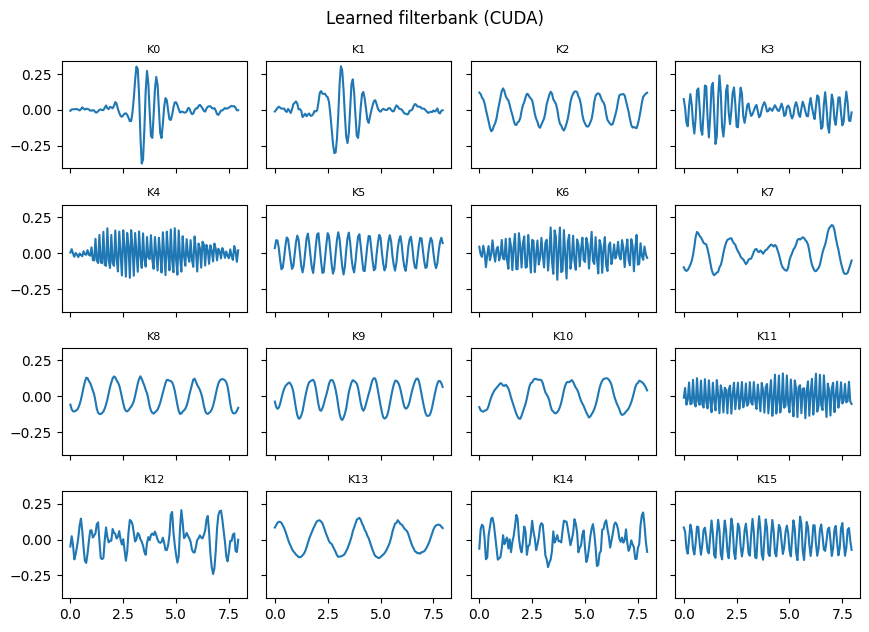

In [10]:
# ------------------ Run everything ------------------

signals, sr = load_audio_from_folder("./audio", sr=16000)
kernels = learn_filterbank(signals)
show_kernels(kernels, sr)

Reconstruction SNR: 8.46 dB


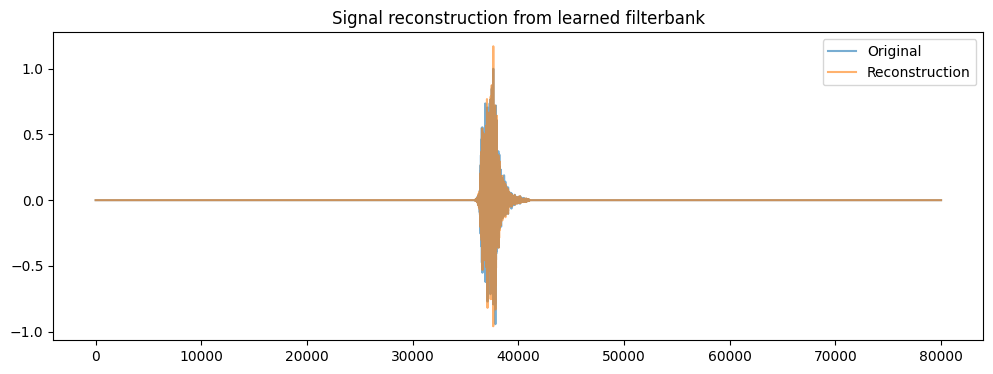

In [11]:
# Pick a test signal
x_test = signals[0]  # from earlier audio loading
signal, recon, encoding = test_reconstruction(x_test.cuda(), kernels.cuda(), stride=50)

# Plot
plt.figure(figsize=(12,4))
plt.plot(signal.numpy(), label="Original", alpha=0.6)
plt.plot(recon.numpy(), label="Reconstruction", alpha=0.6)
plt.legend()
plt.title("Signal reconstruction from learned filterbank")
plt.show()
